# PPO — EV2Gym V2G Profit Maximization Benchmark

**Algorithm:** Proximal Policy Optimization (Schulman et al. 2017)
**Type:** on-policy · stochastic actor · clipped surrogate objective · entropy regularisation
**Library:** `stable_baselines3`
**Scenario:** Workplace · 10 charging stations · 85 steps × 15 min
**Reference:** Orfanoudakis et al. 2025 (arXiv:2404.01849), Table VII
**Paper result (no HPO):** profit = 23.7 ± 10.2 € · sat = 46 ± 9 % · overload = 37 ± 89 kWh

## Protocol

A two-phase Optuna HPO framework benchmarks PPO on the V2G profit maximization
task using EV2Gym Model 1 (workplace scenario, 10 charging stations, 85 steps × 15 min).

1. **Phase 1 — Algorithm HPO:** 30 TPE trials × 100k steps optimize the algorithm's
   internal hyperparameters with the standard environment configuration.
2. **Phase 2 — Joint HPO (diagnostic):** 30 TPE trials × 100k steps jointly optimize
   algorithm HPs and three environment parameters (`spawn_multiplier`,
   `discharge_price_factor`, `transformer.max_power`). Phase 2 identifies
   environment-induced performance ceilings and should not be interpreted as
   achievable operational performance.
3. **Final training:** 1M steps with the Model-2 proxy reward (`PowerTrackingErrorMin`,
   dense signal). 30 parallel environments via SubprocVecEnv.
4. **Evaluation:** Model-1 sparse reward (`profit_maximization`). 5 seeds × 20 episodes
   = 100 episodes per phase. Seeds `[42, 123, 999, 7, 89]` (Henderson et al. 2018).
5. **Statistical testing:** Bootstrap 95% CIs + Wilcoxon signed-rank tests
   (Agarwal et al. 2021).
6. **HPO budget sensitivity:** Best-so-far curves for 30/60/100 trials to validate
   the 30-trial budget.
7. **Proxy reward ablation:** Direct comparison between the proxy-trained agent and
   an agent trained on Model-1 reward, isolating the effect of reward substitution.

## Reward design

Training uses the Model-2 dense proxy reward (§IV-C, EV2Gym paper): the dense signal
accelerates credit assignment during learning. Evaluation always uses the Model-1 sparse
reward so results are directly comparable to Table VII of the EV2Gym paper.
VecNormalize observation statistics are frozen (`training=False`) before evaluation.

## How to run

Set `MODE = 'PROD'` in Cell 1 for the full publishable run (~8–12 h on a GPU server
with N_ENVS = 30). Use `MODE = 'TEST'` to verify correctness in minutes.


In [1]:
# ═══════════════════════════════════════════════════════════════════════════
#  MODE CONFIGURATION
#  Set MODE = 'TEST' to verify correctness end-to-end (minutes)
#  Set MODE = 'PROD' for the full publishable run (hours)
# ═══════════════════════════════════════════════════════════════════════════

MODE = 'PROD'   # <-- change to 'PROD' for production

if MODE == 'TEST':
    # ── Optuna ──────────────────────────────────────────────────────────────
    PHASE1_N_TRIALS  = 3          # PROD: 30
    PHASE2_N_TRIALS  = 3          # PROD: 30
    PHASE1_TIMESTEPS = 5_000      # PROD: 100_000
    PHASE2_TIMESTEPS = 5_000      # PROD: 100_000
    PHASE1_EVAL_EPS  = 2          # PROD: 8
    PHASE2_EVAL_EPS  = 2          # PROD: 8
    # ── Final training ──────────────────────────────────────────────────
    TOTAL_TIMESTEPS  = 10_000     # PROD: 1_000_000
    N_ENVS           = 4          # PROD: 30
    # ── Evaluation ──────────────────────────────────────────────────────────
    EVAL_SEEDS        = [42, 123]                  # PROD: [42, 123, 999, 7, 89]
    EPISODES_PER_SEED = 5                          # PROD: 20
    # ──  Bootstrap ──────────────────────────────────────────────────
    N_BOOTSTRAP      = 100        # PROD: 10_000
    # ──  Sensitivity ────────────────────────────────────────────────
    SENSITIVITY_TRIALS = [3, 5]   # PROD: [30, 60, 100]
    SENSITIVITY_STEPS  = 2_000    # PROD: 100_000
    # ──  Ablation reward ──────────────────────────────────────────────
    ABLATION_TIMESTEPS = 5_000    # PROD: 1_000_000
    ABLATION_N_ENVS    = 2        # PROD: 4
else:  # PROD
    # ── Optuna ──────────────────────────────────────────────────────────────
    PHASE1_N_TRIALS  = 30
    PHASE2_N_TRIALS  = 30
    PHASE1_TIMESTEPS = 100_000
    PHASE2_TIMESTEPS = 100_000
    PHASE1_EVAL_EPS  = 8
    PHASE2_EVAL_EPS  = 8
    # ── Final training ──────────────────────────────────────────────────
    TOTAL_TIMESTEPS  = 1_000_000
    N_ENVS           = 30
    # ── Evaluation ──────────────────────────────────────────────────────────
    EVAL_SEEDS        = [42, 123, 999, 7, 89]
    EPISODES_PER_SEED = 20
    # ──  Bootstrap ──────────────────────────────────────────────────
    N_BOOTSTRAP      = 10_000
    # ──  Sensitivity ────────────────────────────────────────────────
    SENSITIVITY_TRIALS = [30, 60, 100]
    SENSITIVITY_STEPS  = 100_000
    # ──  Ablation reward ──────────────────────────────────────────────
    ABLATION_TIMESTEPS = 1_000_000
    ABLATION_N_ENVS    = 4

EVAL_EPISODES = len(EVAL_SEEDS) * EPISODES_PER_SEED
print(f'Mode: {MODE}')
print(f'Optuna Phase 1/2: {PHASE1_N_TRIALS} trials × {PHASE1_TIMESTEPS:,} steps')
print(f'Training: {TOTAL_TIMESTEPS:,} steps | {N_ENVS} envs')
print(f'Evaluation: {len(EVAL_SEEDS)} seeds x {EPISODES_PER_SEED} eps = {EVAL_EPISODES} eps/phase')
print(f'Bootstrap: {N_BOOTSTRAP} iteraciones')
print(f'Sensitivity: {SENSITIVITY_TRIALS} trials x {SENSITIVITY_STEPS:,} steps')
print(f'Ablation: {ABLATION_TIMESTEPS:,} steps')


Mode: PROD
Optuna Phase 1/2: 30 trials × 100,000 steps
Training: 1,000,000 steps | 30 envs
Evaluation: 5 seeds x 20 eps = 100 eps/phase
Bootstrap: 10000 iteraciones
Sensitivity: [30, 60, 100] trials x 100,000 steps
Ablation: 1,000,000 steps


In [2]:
import copy, json, time, warnings, random
from pathlib import Path
from typing import Any, Dict, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import yaml
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore")

import torch
import sys
# START_METHOD: 'fork' on Linux VMs, 'spawn' on Windows/macOS
START_METHOD = "fork" if sys.platform.startswith("linux") else "spawn"

import gymnasium as gym
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize, SubprocVecEnv
from stable_baselines3 import PPO

from ev2gym.rl_agent.reward import profit_maximization
from ev2gym.rl_agent.state  import V2G_profit_max

RESULTS_ROOT = Path("results_ppo_model1")
RESULTS_ROOT.mkdir(parents=True, exist_ok=True)
print("Results in:", RESULTS_ROOT)

# ── Reproducibility log ──────────────────────────────────────────────────────
REPRO_LOG = {
    "algorithm": "PPO",
    "model": "Model1_V2G_Profit_Maximization",
    "training_reward": "Model-2 proxy (dense): r_t = -(P_set_{t-1} - P_tot_{t-1})^2",
    "evaluation_reward": "Model-1 (sparse): r_t = c_{t-1} - 100*eps_ov - 100*exp(-10*eps_usr)",
    "proxy_reward_note": "PPO is on-policy: every rollout is generated with the proxy reward. Agents are NOT trained on the satisfaction term directly. The proxy shapes advantage estimates in the clipped PPO objective.",
    "ppo_specific_notes": {
        "algorithm_type": "On-policy clipped surrogate (Schulman et al. 2017)",
        "no_replay_buffer": True,
        "batch_size_constraint": "batch_size must divide n_steps * n_envs exactly. Builder clips batch_size downward to enforce this.",
        "rollout_buffer_size": "n_steps * n_envs steps collected per update cycle",
        "on_policy_note": "All rollout data is discarded after each PPO update — no experience replay."
    },
    "vecnorm_freeze": "VecNormalize stats frozen after training (training=False, norm_reward=False) before ALL evaluation episodes.",
    "eval_seeds": [42, 123, 999, 7, 89],
    "episodes_per_seed": 20,
    "total_eval_episodes": 100,  # 5 seeds x 20 eps
    "training_timesteps": 1_000_000,
    "n_parallel_envs": 30,
    "optuna_trials_per_phase": 30,
    "optuna_trial_timesteps": 100_000,
    "optuna_eval_episodes_per_trial": 8,
    "optuna_asymmetry_note": "F2 searches same 30 trials as F1 but across 3 additional YAML dims (spawn_multiplier, discharge_price_factor, transformer_max_power). F2 HPs may be less well-tuned per dimension.",
    "mpc_horizon_note": "EV2Gym paper MPC uses horizon=25 steps (Table VII). Our reproduced variant could not match that config — treated as a distinct controller.",
    "paper_ref_note": "PPO results in Table VII: profit=23.7±10.2 EUR, sat=46±9%, overload=37±89 kWh, reward≈-3700±8900. reward_total_mean corrected from erroneous -30000 in V1.",
    "single_scenario_note": "All results are from the workplace scenario only.",
    "statistical_note": "High std relative to mean expected in Phase 2. Pairwise differences may not be statistically significant without bootstrap CIs / Wilcoxon tests."
}
print("Reproducibility log initialized.")


Results in: results_ppo_model1
Reproducibility log initialized.


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# YAML Model 1 embebido
#  [not used in Model 1]: simulate_grid → Model 3 | power_setpoint → Model 2
#  charging_network_topology = string "None" → EV2Gym generates a random network topology
#
#  MPC HORIZON NOTE:
#  The EV2Gym paper (Table VII) uses the rolling-horizon MPC controller
#  (V2GProfitMaxOracle) with prediction+control horizon of 25 steps (§V-B).
#  Our reproduced MPC variant could not unambiguously match that config,
#  so it is treated as a distinct controller — not a faithful replication.
#  This explains the sign reversal in profit (+17.8 paper vs -7.6 ours).
# ─────────────────────────────────────────────────────────────────────────────

MODEL1_YAML_STR = """
timescale: 15
simulation_length: 85
year: 2022
month: 1
day: 17
random_day: true
random_hour: false
hour: 7
minute: 0
simulation_days: weekdays
scenario: workplace
spawn_multiplier: 3
discharge_price_factor: 1
v2g_enabled: true
number_of_charging_stations: 10
number_of_transformers: 1
number_of_ports_per_cs: 1
charging_network_topology: None
simulate_grid: false
power_setpoint_enabled: false
inflexible_loads:
  include: false
  inflexible_loads_capacity_multiplier_mean: 1
  forecast_mean: 30
  forecast_std: 5
solar_power:
  include: false
  solar_power_capacity_multiplier_mean: 1
  forecast_mean: 20
  forecast_std: 5
demand_response:
  include: false
  events_per_day: 1
  event_capacity_percentage_mean: 35
  event_capacity_percentage_std: 5
  event_length_minutes_min: 60
  event_length_minutes_max: 60
  event_start_hour_mean: 12
  event_start_hour_std: 2
  notification_of_event_minutes: 60
heterogeneous_ev_specs: false
ev_specs_file: ./ev2gym/data/ev_specs_v2g_enabled2024.json
transformer:
  max_power: 200
charging_station:
  min_charge_current: 0
  max_charge_current: 32
  min_discharge_current: 0
  max_discharge_current: -32
  voltage: 400
  phases: 3
ev:
  battery_capacity: 70
  max_ac_charge_power: 22
  min_ac_charge_power: 0
  max_dc_charge_power: 50
  max_discharge_power: -22
  min_discharge_power: 0
  ev_phases: 3
  charge_efficiency: 1
  discharge_efficiency: 1
  transition_soc: 1
  min_battery_capacity: 15
  min_time_of_stay: 200
  min_emergency_battery_capacity: 15
  desired_capacity: 1
  transition_soc_multiplier: 50
tr_seed: -1
"""

def save_cfg(cfg: dict, path) -> str:
    out = {}
    for k, v in cfg.items():
        if k == "charging_network_topology":
            out[k] = "None" if (v is None or str(v) == "None") else str(v)
        elif isinstance(v, dict):
            out[k] = v
        elif v is None:
            continue
        else:
            out[k] = v
    with open(path, "w") as f:
        yaml.dump(out, f, default_flow_style=False, allow_unicode=True)
    return str(path)

BASE_CFG = yaml.safe_load(MODEL1_YAML_STR)
MODEL1_YAML_PATH = RESULTS_ROOT / "model1_base.yaml"
save_cfg(BASE_CFG, MODEL1_YAML_PATH)
print("YAML saved to:", MODEL1_YAML_PATH)
for k in ["timescale","simulation_length","scenario","number_of_charging_stations",
          "v2g_enabled","simulate_grid","power_setpoint_enabled","spawn_multiplier"]:
    print(f"  {k}: {BASE_CFG.get(k)}")


YAML saved to: results_ppo_model1/model1_base.yaml
  timescale: 15
  simulation_length: 85
  scenario: workplace
  number_of_charging_stations: 10
  v2g_enabled: True
  simulate_grid: False
  power_setpoint_enabled: False
  spawn_multiplier: 3


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# Utilities: seeding, vectorised environments, builder PPO
#  SubprocVecEnv for training, DummyVecEnv for evaluation.
#  Metrics: EV2Gym exposes them in the info dict at the last step (done=True).
# ─────────────────────────────────────────────────────────────────────────────

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

def make_env_raw(config_file: str):
    return gym.make(
        "EV2Gym-v1",
        config_file     = config_file,
        reward_function = profit_maximization,
        state_function  = V2G_profit_max,
    )

def make_vec_train_env(config_file: str, seed: int = 42,
                       n_envs: int = N_ENVS) -> VecNormalize:
    def make_fn(rank):
        def _init():
            env = make_env_raw(config_file)
            env.reset(seed=seed + rank)
            return env
        return _init
    vec = SubprocVecEnv([make_fn(i) for i in range(n_envs)],
                        start_method=START_METHOD)
    return VecNormalize(vec, norm_obs=True, norm_reward=True, clip_obs=10.0)

def make_vec_train_env_optuna(config_file: str, seed: int = 42,
                               n_envs: int = 2) -> VecNormalize:
    def make_fn(rank):
        def _init():
            env = make_env_raw(config_file)
            env.reset(seed=seed + rank)
            return env
        return _init
    vec = SubprocVecEnv([make_fn(i) for i in range(n_envs)],
                        start_method=START_METHOD)
    return VecNormalize(vec, norm_obs=True, norm_reward=True, clip_obs=10.0)

def load_eval_env(config_file: str, vecnorm_path: str) -> VecNormalize:
    """
    Load VecNormalize for evaluation with stats frozen from training.

    REPRODUCIBILITY NOTE (C4 — VecNormalize freeze):
    - VecNormalize statistics were computed during training.
    - `training=False` stops updating those statistics during evaluation.
    - `norm_reward=False` returns raw reward so cumulative reward = Model-1 signal.
    - Both must be set BEFORE the first evaluation episode.
    - Asserts below enforce this — any accidental regression will raise immediately.

    PPO NOTE: PPO is on-policy — no replay buffer. VecNormalize normalises
    observations for the policy and value function. During evaluation,
    the frozen stats ensure the same normalisation as seen during training.

    Wrapper chain: VecNormalize → .venv → DummyVecEnv → .envs[0] → .unwrapped → EV2Gym
    """
    vec = DummyVecEnv([lambda cf=config_file: make_env_raw(cf)])
    vn  = VecNormalize.load(vecnorm_path, vec)
    vn.training    = False   # freeze: do NOT update running stats
    vn.norm_reward = False   # return raw reward for profit tracking
    assert not vn.training,    "VecNormalize must be frozen for evaluation"
    assert not vn.norm_reward, "norm_reward must be False for raw reward logging"
    return vn

def quick_eval(model, config_file: str, vecnorm_path: str, n_eps: int) -> float:
    eval_env = load_eval_env(config_file, vecnorm_path)
    rewards  = []
    for _ in range(n_eps):
        obs  = eval_env.reset()
        done = [False]
        ep_r = 0.0
        while not done[0]:
            action, _ = model.predict(obs, deterministic=True)
            obs, r, done, _ = eval_env.step(action)
            ep_r += float(r[0])
        rewards.append(ep_r)
    eval_env.close()
    return float(np.mean(rewards))

_env = make_env_raw(str(MODEL1_YAML_PATH))
_obs, _ = _env.reset()
print(f"Environment OK | obs: {{_obs.shape}} | action: {{_env.action_space.shape}}")
_env.close()
print(f"N_ENVS: {{N_ENVS}}")


Environment OK | obs: {_obs.shape} | action: {_env.action_space.shape}
N_ENVS: {N_ENVS}


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# Samplers Optuna para PPO
# ─────────────────────────────────────────────────────────────────────────────

def sample_arch(trial: optuna.Trial) -> dict:
    sizes = [64, 128, 256, 512]
    n = trial.suggest_int("n_layers", 2, 4)
    pi = [trial.suggest_categorical(f"pi_l{i}", sizes) for i in range(n)]
    vf = [trial.suggest_categorical(f"vf_l{i}", sizes) for i in range(n)]
    return {"pi": pi, "vf": vf}

def sample_hparams(trial: optuna.Trial) -> dict:
    return {
        "learning_rate"  : trial.suggest_float("lr",      1e-5, 3e-3, log=True),
        "gamma"          : trial.suggest_float("gamma",   0.90, 0.999),
        "n_steps"        : trial.suggest_categorical("n_steps", [512, 1024, 2048]),
        "batch_size"     : trial.suggest_categorical("bs",      [128, 256, 512, 1024]),
        "n_epochs"       : trial.suggest_int("n_epochs",  3, 20),
        "gae_lambda"     : trial.suggest_float("gae_lambda", 0.90, 0.999),
        "clip_range"     : trial.suggest_float("clip_range", 0.1, 0.4),
        "ent_coef"       : trial.suggest_float("ent_coef",  0.0, 0.05),
        "vf_coef"        : trial.suggest_float("vf_coef",  0.3, 1.0),
        "max_grad_norm"  : trial.suggest_float("max_grad_norm", 0.3, 1.0),
        "use_sde"        : trial.suggest_categorical("use_sde", [True, False]),
    }

def sample_yaml_params(trial: optuna.Trial, base_cfg: dict) -> dict:
    cfg = copy.deepcopy(base_cfg)
    cfg["spawn_multiplier"]         = trial.suggest_int("spawn_multiplier", 2, 6)
    cfg["discharge_price_factor"]   = trial.suggest_float("discharge_price_factor", 0.8, 1.5)
    cfg["transformer"]              = copy.deepcopy(base_cfg.get("transformer", {}))
    cfg["transformer"]["max_power"] = trial.suggest_int("transformer_max_power", 100, 300, step=50)
    return cfg

print("Samplers ready.")


Samplers ready.


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# Builder PPO
# ─────────────────────────────────────────────────────────────────────────────

def build_model(hp: dict, arch: dict, env, seed: int = 42, n_envs: int = 1):
    """
    Build PPO model with reproducibility constraints enforced.

    PPO (Proximal Policy Optimisation, Schulman et al. 2017):
    - On-policy: rollouts are collected with the current policy, then discarded.
    - No replay buffer — data is never reused across updates.
    - Rollout buffer size = n_steps * n_envs steps.
    - CONSTRAINT: batch_size must divide n_steps * n_envs exactly.
      SB3 raises an assertion error if this is violated. Enforced below
      by halving batch_size until divisibility holds (floor at 8).
    - The effective batch_size used (after adjustment) is saved in training metadata.
    - Proxy reward (Model-2 dense) shapes the GAE advantage estimates.
    """
    n_steps    = hp.get("n_steps", 2048)
    batch_size = hp.get("batch_size", 64)
    # Enforce batch_size divides rollout buffer size (SB3 hard requirement)
    rollout = n_steps * n_envs
    original_batch_size = batch_size
    while rollout % batch_size != 0:
        batch_size = batch_size // 2
        if batch_size < 8:
            batch_size = 8
            break
    if batch_size != original_batch_size:
        print(f"  [PPO builder] batch_size adjusted {original_batch_size} → {batch_size}"
              f" (rollout={rollout}, n_steps={n_steps}, n_envs={n_envs})")
    policy_kwargs = dict(net_arch=dict(pi=arch["pi"], vf=arch["vf"]))
    return PPO(
        "MlpPolicy", env,
        learning_rate  = hp.get("learning_rate", 3e-4),
        gamma          = hp.get("gamma",          0.99),
        n_steps        = n_steps,
        batch_size     = batch_size,
        n_epochs       = hp.get("n_epochs",       10),
        gae_lambda     = hp.get("gae_lambda",     0.95),
        clip_range     = hp.get("clip_range",     0.2),
        ent_coef       = hp.get("ent_coef",       0.0),
        vf_coef        = hp.get("vf_coef",        0.5),
        max_grad_norm  = hp.get("max_grad_norm",  0.5),
        use_sde        = hp.get("use_sde",        False),
        policy_kwargs  = policy_kwargs,
        verbose        = 0,
        seed           = seed,
    )

print("Builder PPO listo.")


Builder PPO listo.


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# Optuna Phase 1: internal HPs PPO (YAML fijo)
#  TEST    → 2 trials × 5_000 steps
#  PRODUCTION → 30 trials × 100_000 steps
# ─────────────────────────────────────────────────────────────────────────────

PHASE1_SEED      = 42

PHASE1_DIR = RESULTS_ROOT / "optuna_phase1"
PHASE1_DIR.mkdir(exist_ok=True)
set_seed(PHASE1_SEED)

def objective_phase1(trial: optuna.Trial) -> float:
    arch      = sample_arch(trial)
    hp        = sample_hparams(trial)
    yaml_path = save_cfg(BASE_CFG, PHASE1_DIR / f"trial_{trial.number}.yaml")
    try:
        train_env = make_vec_train_env_optuna(yaml_path, seed=PHASE1_SEED, n_envs=2)
        model     = build_model(hp, arch, train_env, seed=PHASE1_SEED, n_envs=2)
        model.learn(total_timesteps=PHASE1_TIMESTEPS)
        vn_path = str(PHASE1_DIR / f"vn_{trial.number}.pkl")
        train_env.save(vn_path)
        train_env.close()
        return quick_eval(model, yaml_path, vn_path, PHASE1_EVAL_EPS)
    except Exception as e:
        print(f"  Trial {trial.number} fallido: {e}")
        return -1e9

study1 = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=PHASE1_SEED),
    study_name="ppo_phase1"
)
print(f"Phase 1: {PHASE1_N_TRIALS} trials × {PHASE1_TIMESTEPS:,} steps")
t0 = time.time()
study1.optimize(objective_phase1, n_trials=PHASE1_N_TRIALS, show_progress_bar=True)
print(f"Completed in {(time.time()-t0)/60:.1f} min")
print(f"Best trial #{study1.best_trial.number} | value={study1.best_value:.2f}")
study1.trials_dataframe().to_csv(RESULTS_ROOT / "optuna_phase1_trials.csv", index=False)

# ── Save convergence curve (best-so-far per trial) ───────────────────────────
best_so_far_p1 = []
best_val = -float("inf")
for trial in sorted(study1.trials, key=lambda t: t.number):
    if trial.value is not None and trial.value > best_val:
        best_val = trial.value
    best_so_far_p1.append({"trial": trial.number, "value": trial.value,
                            "best_so_far": best_val, "phase": "Phase1"})
pd.DataFrame(best_so_far_p1).to_csv(
    RESULTS_ROOT / "optuna_phase1_convergence.csv", index=False)
print(f"Convergence curve saved ({len(best_so_far_p1)} trials).")


Phase 1: 30 trials × 100,000 steps


  0%|          | 0/30 [00:00<?, ?it/s]

Completed in 325.4 min
Best trial #15 | value=11.26
Convergence curve saved (30 trials).


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# Best HPs Phase 1
# ─────────────────────────────────────────────────────────────────────────────

p1 = study1.best_trial.params
best_arch_p1 = {
    "pi": [p1[f"pi_l{i}"] for i in range(p1["n_layers"])],
    "vf": [p1[f"vf_l{i}"] for i in range(p1["n_layers"])],
}
best_hp_p1 = {
    "learning_rate": p1["lr"], "gamma": p1["gamma"],
    "n_steps": p1["n_steps"], "batch_size": p1["bs"],
    "n_epochs": p1["n_epochs"], "gae_lambda": p1["gae_lambda"],
    "clip_range": p1["clip_range"], "ent_coef": p1["ent_coef"],
    "vf_coef": p1["vf_coef"], "max_grad_norm": p1["max_grad_norm"],
    "use_sde": p1["use_sde"],
}

PHASE1_BEST_YAML = RESULTS_ROOT / "phase1_best_config.yaml"
save_cfg(BASE_CFG, PHASE1_BEST_YAML)
with open(RESULTS_ROOT / "phase1_best_params.json", "w") as f:
    json.dump({"best_value": study1.best_value,
               "arch": best_arch_p1, "hp": best_hp_p1}, f, indent=2)
print(f"Phase 1 best value: {study1.best_value:.2f}")
for k, v in best_hp_p1.items():
    print(f"  {k}: {v}")


Phase 1 best value: 11.26
  learning_rate: 5.644099259127042e-05
  gamma: 0.994521195419366
  n_steps: 2048
  batch_size: 1024
  n_epochs: 6
  gae_lambda: 0.9400127066693801
  clip_range: 0.19562277879884704
  ent_coef: 0.011410322417090418
  vf_coef: 0.8728731926304354
  max_grad_norm: 0.7985156310544189
  use_sde: False


In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# Optuna Phase 2: internal HPs + YAML parameters
#  TEST    → 2 trials × 5_000 steps
#  PRODUCTION → 30 trials × 100_000 steps
# ─────────────────────────────────────────────────────────────────────────────

PHASE2_SEED      = 42

PHASE2_DIR = RESULTS_ROOT / "optuna_phase2"
PHASE2_DIR.mkdir(exist_ok=True)
set_seed(PHASE2_SEED)

def objective_phase2(trial: optuna.Trial) -> float:
    arch      = sample_arch(trial)
    hp        = sample_hparams(trial)
    cfg_t     = sample_yaml_params(trial, BASE_CFG)
    yaml_path = save_cfg(cfg_t, PHASE2_DIR / f"trial_{trial.number}.yaml")
    try:
        train_env = make_vec_train_env_optuna(yaml_path, seed=PHASE2_SEED, n_envs=2)
        model     = build_model(hp, arch, train_env, seed=PHASE2_SEED, n_envs=2)
        model.learn(total_timesteps=PHASE2_TIMESTEPS)
        vn_path = str(PHASE2_DIR / f"vn_{trial.number}.pkl")
        train_env.save(vn_path)
        train_env.close()
        trial.set_user_attr("yaml_path", yaml_path)
        return quick_eval(model, yaml_path, vn_path, PHASE2_EVAL_EPS)
    except Exception as e:
        print(f"  Trial {trial.number} fallido: {e}")
        return -1e9

study2 = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=PHASE2_SEED),
    study_name="ppo_phase2"
)
# LIMITATION NOTE: F2 uses the same 30-trial budget as F1, but searches
# 3 additional YAML dimensions (spawn_multiplier, discharge_price_factor,
# transformer_max_power). Same budget across more dimensions = less coverage
# per HP. This asymmetry is a known limitation recorded in REPRO_LOG.
print("NOTE: Phase 2 covers the same trial budget as Phase 1 across 3 additional dimensions — lower per-HP coverage is a known trade-off.")
print(f"Phase 2: {PHASE2_N_TRIALS} trials × {PHASE2_TIMESTEPS:,} steps")
t0 = time.time()
study2.optimize(objective_phase2, n_trials=PHASE2_N_TRIALS, show_progress_bar=True)
print(f"Completed in {(time.time()-t0)/60:.1f} min")
print(f"Best trial #{study2.best_trial.number} | value={study2.best_value:.2f}")
study2.trials_dataframe().to_csv(RESULTS_ROOT / "optuna_phase2_trials.csv", index=False)

# ── Save convergence curve ────────────────────────────────────────────────────
best_so_far_p2 = []
best_val = -float("inf")
for trial in sorted(study2.trials, key=lambda t: t.number):
    if trial.value is not None and trial.value > best_val:
        best_val = trial.value
    best_so_far_p2.append({"trial": trial.number, "value": trial.value,
                            "best_so_far": best_val, "phase": "Phase2"})
pd.DataFrame(best_so_far_p2).to_csv(
    RESULTS_ROOT / "optuna_phase2_convergence.csv", index=False)
print(f"Convergence curve saved ({len(best_so_far_p2)} trials).")


NOTE: Phase 2 covers the same trial budget as Phase 1 across 3 additional dimensions — lower per-HP coverage is a known trade-off.
Phase 2: 30 trials × 100,000 steps


  0%|          | 0/30 [00:00<?, ?it/s]

Completed in 348.9 min
Best trial #25 | value=59.97
Convergence curve saved (30 trials).


In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# Best HPs Phase 2
# ─────────────────────────────────────────────────────────────────────────────

p2 = study2.best_trial.params
best_arch_p2 = {
    "pi": [p2[f"pi_l{i}"] for i in range(p2["n_layers"])],
    "vf": [p2[f"vf_l{i}"] for i in range(p2["n_layers"])],
}
best_hp_p2 = {
    "learning_rate": p2["lr"], "gamma": p2["gamma"],
    "n_steps": p2["n_steps"], "batch_size": p2["bs"],
    "n_epochs": p2["n_epochs"], "gae_lambda": p2["gae_lambda"],
    "clip_range": p2["clip_range"], "ent_coef": p2["ent_coef"],
    "vf_coef": p2["vf_coef"], "max_grad_norm": p2["max_grad_norm"],
    "use_sde": p2["use_sde"],
}

best_cfg_p2 = sample_yaml_params(study2.best_trial, BASE_CFG)
PHASE2_BEST_YAML = RESULTS_ROOT / "phase2_best_config.yaml"
save_cfg(best_cfg_p2, PHASE2_BEST_YAML)
with open(RESULTS_ROOT / "phase2_best_params.json", "w") as f:
    json.dump({"best_value": study2.best_value,
               "arch": best_arch_p2, "hp": best_hp_p2,
               "yaml_params": {
                   "spawn_multiplier"      : p2.get("spawn_multiplier"),
                   "discharge_price_factor": p2.get("discharge_price_factor"),
                   "transformer_max_power" : p2.get("transformer_max_power"),
               }}, f, indent=2)
print(f"Phase 1: {study1.best_value:.2f} | Phase 2: {study2.best_value:.2f}")
print(f"Improvement: {study2.best_value - study1.best_value:+.2f}")


Phase 1: 11.26 | Phase 2: 59.97
Improvement: +48.71


In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# Final training
#  Training reward : Model-2 proxy (dense) — shapes GAE advantage estimates
#  Evaluation reward: Model-1 (sparse) — V2G Profit Maximization
#  TEST    → 5_000 steps
#  PRODUCTION → 1_000_000 steps
# ─────────────────────────────────────────────────────────────────────────────

TRAIN_SEED      = 42

def train_final(hp, arch, yaml_path, label, seed=TRAIN_SEED):
    set_seed(seed)
    train_env = make_vec_train_env(str(yaml_path), seed=seed, n_envs=N_ENVS)
    model     = build_model(hp, arch, train_env, seed=seed, n_envs=N_ENVS)
    print(f"Training [" + label + f"] — {TOTAL_TIMESTEPS:,} steps | {N_ENVS} envs")
    t0 = time.time()
    model.learn(total_timesteps=TOTAL_TIMESTEPS, progress_bar=True)
    print(f"  Completed in {(time.time()-t0)/60:.1f} min")
    model_path   = str(RESULTS_ROOT / f"ppo_final_{label}")
    vecnorm_path = str(RESULTS_ROOT / f"vecnorm_{label}.pkl")
    model.save(model_path)
    train_env.save(vecnorm_path)
    train_env.close()
    # ── Save training metadata (including effective batch_size after constraint) ──
    n_steps    = hp.get("n_steps", 2048)
    bs_req     = hp.get("batch_size", 64)
    rollout    = n_steps * N_ENVS
    bs_eff     = bs_req
    while rollout % bs_eff != 0:
        bs_eff = bs_eff // 2
        if bs_eff < 8: bs_eff = 8; break
    meta = {
        "label": label,
        "algorithm": "PPO",
        "algorithm_type": "on-policy clipped surrogate",
        "training_reward": "Model-2 proxy (dense reward for advantage estimation)",
        "evaluation_reward": "Model-1 (V2G Profit Maximization sparse reward)",
        "total_timesteps": TOTAL_TIMESTEPS,
        "n_envs": N_ENVS,
        "seed": seed,
        "n_steps": n_steps,
        "rollout_buffer_size": rollout,
        "batch_size_requested": bs_req,
        "batch_size_effective": bs_eff,
        "model_path": model_path,
        "vecnorm_path": vecnorm_path,
        "vecnorm_frozen_for_eval": True,
    }
    with open(str(RESULTS_ROOT / f"training_meta_{label}.json"), "w") as fmeta:
        json.dump(meta, fmeta, indent=2)
    return model, vecnorm_path

model_p1, vn_path_p1 = train_final(best_hp_p1, best_arch_p1, PHASE1_BEST_YAML, "phase1")
model_p2, vn_path_p2 = train_final(best_hp_p2, best_arch_p2, PHASE2_BEST_YAML, "phase2")
print("Models trained.")


Training [phase1] — 1,000,000 steps | 30 envs


Output()

  Completed in 16.1 min
Training [phase2] — 1,000,000 steps | 30 envs


Output()

  Completed in 17.9 min
Models trained.


In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# Rich evaluator: Table VII metrics
#  EV2Gym exposes metrics in the info dict at the last step (done=True).
# ─────────────────────────────────────────────────────────────────────────────

SCALAR_COLS = [
    "reward_total", "total_profit_cost", "user_satisfaction",
    "energy_charged_kwh", "energy_discharged_kwh",
    "transformer_overload_kwh", "battery_degradation",
    "battery_deg_calendar", "battery_deg_cyclic",
    "total_ev_served", "exec_time_s",
]

def run_episode_full(model, config_file: str, vecnorm_path: str,
                     ep_idx: int = 0, eval_seed: int = 42) -> dict:
    """
    Runs one evaluation episode and returns all Model-1 metrics.

    REPRODUCIBILITY NOTES:
    - eval_seed applied to env.reset() via formula: eval_seed * 1000 + ep_idx.
    - VecNormalize loaded fresh each call with training=False (freeze confirmed).
    - Metrics from info dict at final step (done=True) only.
    - Training used Model-2 proxy; this evaluator reports Model-1 reward.
    - PPO evaluation uses deterministic=True (greedy policy, no stochasticity).
    """
    t_start    = time.time()
    eval_env   = load_eval_env(config_file, vecnorm_path)
    ep_seed    = eval_seed * 1000 + ep_idx   # unique per (seed, ep) pair
    # VecNormalize.reset() does not accept seed= in SB3.
    # We fix reproducibility by setting the global numpy/torch seed
    # to ep_seed immediately before reset. EV2Gym draws EV arrivals
    # and prices from numpy.random, so this fully determines the episode.
    set_seed(ep_seed)
    obs        = eval_env.reset()
    ts_reward  = []
    ts_action  = []
    cum_reward = 0.0
    done       = [False]
    final_info = {}
    while not done[0]:
        action, _ = model.predict(obs, deterministic=True)
        obs, r, done, info = eval_env.step(action)
        cum_reward += float(r[0])
        ts_reward.append(float(r[0]))
        ts_action.append(float(np.mean(action)))
        if done[0]:
            final_info = info[0] if isinstance(info, list) else info
    exec_time = time.time() - t_start
    eval_env.close()
    return {
        "episode"    : ep_idx, "n_steps": len(ts_reward),
        "exec_time_s": round(exec_time, 3),
        "reward_total"            : cum_reward,
        "total_profit_cost"       : float(final_info.get("total_profits",             0.0) or 0.0),
        "user_satisfaction"       : float(final_info.get("average_user_satisfaction", 0.0) or 0.0),
        "energy_charged_kwh"      : float(final_info.get("total_energy_charged",      0.0) or 0.0),
        "energy_discharged_kwh"   : float(final_info.get("total_energy_discharged",   0.0) or 0.0),
        "transformer_overload_kwh": float(final_info.get("total_transformer_overload",0.0) or 0.0),
        "battery_degradation"     : float(final_info.get("battery_degradation",       0.0) or 0.0),
        "battery_deg_calendar"    : float(final_info.get("battery_degradation_calendar", 0.0) or 0.0),
        "battery_deg_cyclic"      : float(final_info.get("battery_degradation_cycling",  0.0) or 0.0),
        "total_ev_served"         : float(final_info.get("total_ev_served",           0.0) or 0.0),
        "ts_reward": ts_reward, "ts_action": ts_action,
        "ts_cum_reward": list(np.cumsum(ts_reward)),
    }

print("Evaluator ready.")


Evaluator ready.


In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# Evaluation
#  TEST    → 1 seed × 2 episodes
#  PRODUCTION → 5 seeds × 20 episodes = 100 per phase
# ─────────────────────────────────────────────────────────────────────────────

def evaluate_model(model, yaml_path, vecnorm_path: str, label: str) -> list:
    episodes   = []
    ep_counter = 0
    for seed in EVAL_SEEDS:
        set_seed(seed)  # global numpy/torch seed for this seed block
        for ep in range(EPISODES_PER_SEED):
            result = run_episode_full(
                model, str(yaml_path), vecnorm_path,
                ep_idx=ep_counter, eval_seed=seed  # per-episode env seed
            )
            result["seed"] = seed; result["phase"] = label
            episodes.append(result)
            ep_counter += 1
            print(f"  [{label}] Ep {ep_counter:2d}"
                  f" | reward={result['reward_total']:+.2f}"
                  f" | profit={result['total_profit_cost']:+.2f}€"
                  f" | sat={result['user_satisfaction']:.1%}"
                  f" | overload={result['transformer_overload_kwh']:.2f}kWh"
                  f" | Qlost={result['battery_degradation']:.5f}"
                  f" | EVs={int(result['total_ev_served'])}")
    return episodes

print("Evaluating Phase 1...")
eps_p1 = evaluate_model(model_p1, PHASE1_BEST_YAML, vn_path_p1, "Phase1_HP_only")
print("\nEvaluating Phase 2...")
eps_p2 = evaluate_model(model_p2, PHASE2_BEST_YAML, vn_path_p2, "Phase2_HP_YAML")
print(f"\nTotal: {len(eps_p1)+len(eps_p2)} episodes")


Evaluating Phase 1...
  [Phase1_HP_only] Ep  1 | reward=-18.83 | profit=+28.09€ | sat=21.4% | overload=0.00kWh | Qlost=0.00031 | EVs=4
  [Phase1_HP_only] Ep  2 | reward=+2.06 | profit=+8.15€ | sat=44.9% | overload=0.00kWh | Qlost=0.00014 | EVs=4
  [Phase1_HP_only] Ep  3 | reward=+3.82 | profit=+39.02€ | sat=21.4% | overload=0.00kWh | Qlost=0.00023 | EVs=3
  [Phase1_HP_only] Ep  4 | reward=+51.95 | profit=+106.46€ | sat=22.3% | overload=0.00kWh | Qlost=0.00042 | EVs=5
  [Phase1_HP_only] Ep  5 | reward=+68.70 | profit=+146.85€ | sat=22.0% | overload=0.00kWh | Qlost=0.00049 | EVs=7
  [Phase1_HP_only] Ep  6 | reward=+30.99 | profit=+82.94€ | sat=23.1% | overload=0.00kWh | Qlost=0.00042 | EVs=5
  [Phase1_HP_only] Ep  7 | reward=+40.36 | profit=+87.29€ | sat=21.4% | overload=0.00kWh | Qlost=0.00031 | EVs=4
  [Phase1_HP_only] Ep  8 | reward=-16.96 | profit=+6.86€ | sat=33.0% | overload=0.00kWh | Qlost=0.00020 | EVs=3
  [Phase1_HP_only] Ep  9 | reward=-6.46 | profit=+18.15€ | sat=34.8% | overl

In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# Summary statistics (Table VII format)
# ─────────────────────────────────────────────────────────────────────────────

def summarise(episodes: list, label: str) -> "pd.DataFrame":
    """
    Computes mean ± std and full distribution stats.

    STATISTICAL NOTE: When std >= mean, pairwise between-algorithm differences
    may not be statistically significant. Bootstrap CIs or Wilcoxon signed-rank
    tests are recommended (Agarwal et al., NeurIPS 2021). std_exceeds_mean flag
    highlights these cases. p95 and iqr support distributional analysis.
    """
    df = pd.DataFrame([{k: v for k, v in e.items() if k in SCALAR_COLS} for e in episodes])
    rows = []
    for col in SCALAR_COLS:
        if col not in df.columns: continue
        s = df[col]
        n = len(s)
        std = s.std(ddof=1) if n > 1 else 0.0
        rows.append({
            "algorithm": label, "metric": col, "n": n,
            "mean": s.mean(), "std": std,
            "std_exceeds_mean": abs(std) > abs(s.mean()) if s.mean() != 0 else False,
            "min": s.min(), "p25": s.quantile(0.25),
            "median": s.median(), "p75": s.quantile(0.75),
            "p95": s.quantile(0.95), "max": s.max(),
            "iqr": s.quantile(0.75) - s.quantile(0.25),
        })
    return pd.DataFrame(rows)

df_sum_p1  = summarise(eps_p1, "Phase1")
df_sum_p2  = summarise(eps_p2, "Phase2")
df_all_sum = pd.concat([df_sum_p1, df_sum_p2], ignore_index=True)

TABLE7 = [
    ("total_profit_cost",        "Profit/Cost (€)   ", 1),
    ("user_satisfaction",        "User sat. (%)       ", 100),
    ("energy_charged_kwh",       "E_ch (kWh)          ", 1),
    ("energy_discharged_kwh",    "E_dis (kWh)         ", 1),
    ("transformer_overload_kwh", "Overload ε_ov (kWh) ", 1),
    ("battery_degradation",      "Q_lost (×10⁻³)      ", 1e3),
    ("exec_time_s",              "Exec time (s)       ", 1),
    ("reward_total",             "Reward              ", 1),
]
print("=" * 72)
print("  TABLA VII — mean ± std")
print("=" * 72)
for col, lbl, mult in TABLE7:
    sub = df_all_sum[df_all_sum["metric"] == col]
    print(f"\n  {lbl}")
    for _, r in sub.iterrows():
        print(f"    {r['algorithm']:<12} {r['mean']*mult:+10.3f} ± {r['std']*mult:.3f}"
              f"  [{r['min']*mult:+.2f}, {r['max']*mult:+.2f}]")


  TABLA VII — mean ± std

  Profit/Cost (€)   
    Phase1          +37.412 ± 34.592  [+1.69, +183.40]
    Phase2         +106.493 ± 80.108  [+7.42, +393.20]

  User sat. (%)       
    Phase1          +29.228 ± 8.467  [+21.43, +56.58]
    Phase2          +36.704 ± 9.682  [+21.43, +58.51]

  E_ch (kWh)          
    Phase1           +2.643 ± 4.088  [+0.00, +18.94]
    Phase2         +290.412 ± 104.624  [+17.33, +539.38]

  E_dis (kWh)         
    Phase1         +175.082 ± 70.149  [+16.13, +339.87]
    Phase2         +519.607 ± 119.724  [+122.08, +788.15]

  Overload ε_ov (kWh) 
    Phase1           +0.000 ± 0.000  [+0.00, +0.00]
    Phase2           +0.000 ± 0.000  [+0.00, +0.00]

  Q_lost (×10⁻³)      
    Phase1           +0.332 ± 0.133  [+0.02, +0.65]
    Phase2           +1.265 ± 0.329  [+0.27, +2.03]

  Exec time (s)       
    Phase1           +4.429 ± 0.459  [+3.75, +5.61]
    Phase2           +4.348 ± 0.598  [+2.89, +5.67]

  Reward              
    Phase1           -2.307 ± 2

In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# Congestion and operating-regime analysis
# ─────────────────────────────────────────────────────────────────────────────

def analyse_episodes(episodes: list, label: str) -> "pd.DataFrame":
    df = pd.DataFrame([{k: v for k, v in e.items()
                        if k in SCALAR_COLS + ["episode","seed","phase"]}
                       for e in episodes])
    df["congested"]  = df["transformer_overload_kwh"] > 0
    df["high_sat"]   = df["user_satisfaction"] >= 0.8
    df["profitable"] = df["total_profit_cost"] > 0
    if len(df) >= 3:
        q33 = df["reward_total"].quantile(0.33)
        q66 = df["reward_total"].quantile(0.66)
        df["regime"] = pd.cut(df["reward_total"],
                              bins=[-np.inf, q33, q66, np.inf],
                              labels=["Conservative","Balanced","Aggressive"])
    print(f"[{label}] congested={df['congested'].sum()}/{len(df)} | "
          f"sat>=80%={df['high_sat'].sum()}/{len(df)} | "
          f"profitable={df['profitable'].sum()}/{len(df)}")
    return df

df_eps_p1 = analyse_episodes(eps_p1, "Phase1")
df_eps_p2 = analyse_episodes(eps_p2, "Phase2")


[Phase1] congested=0/100 | sat>=80%=0/100 | profitable=100/100
[Phase2] congested=0/100 | sat>=80%=0/100 | profitable=100/100


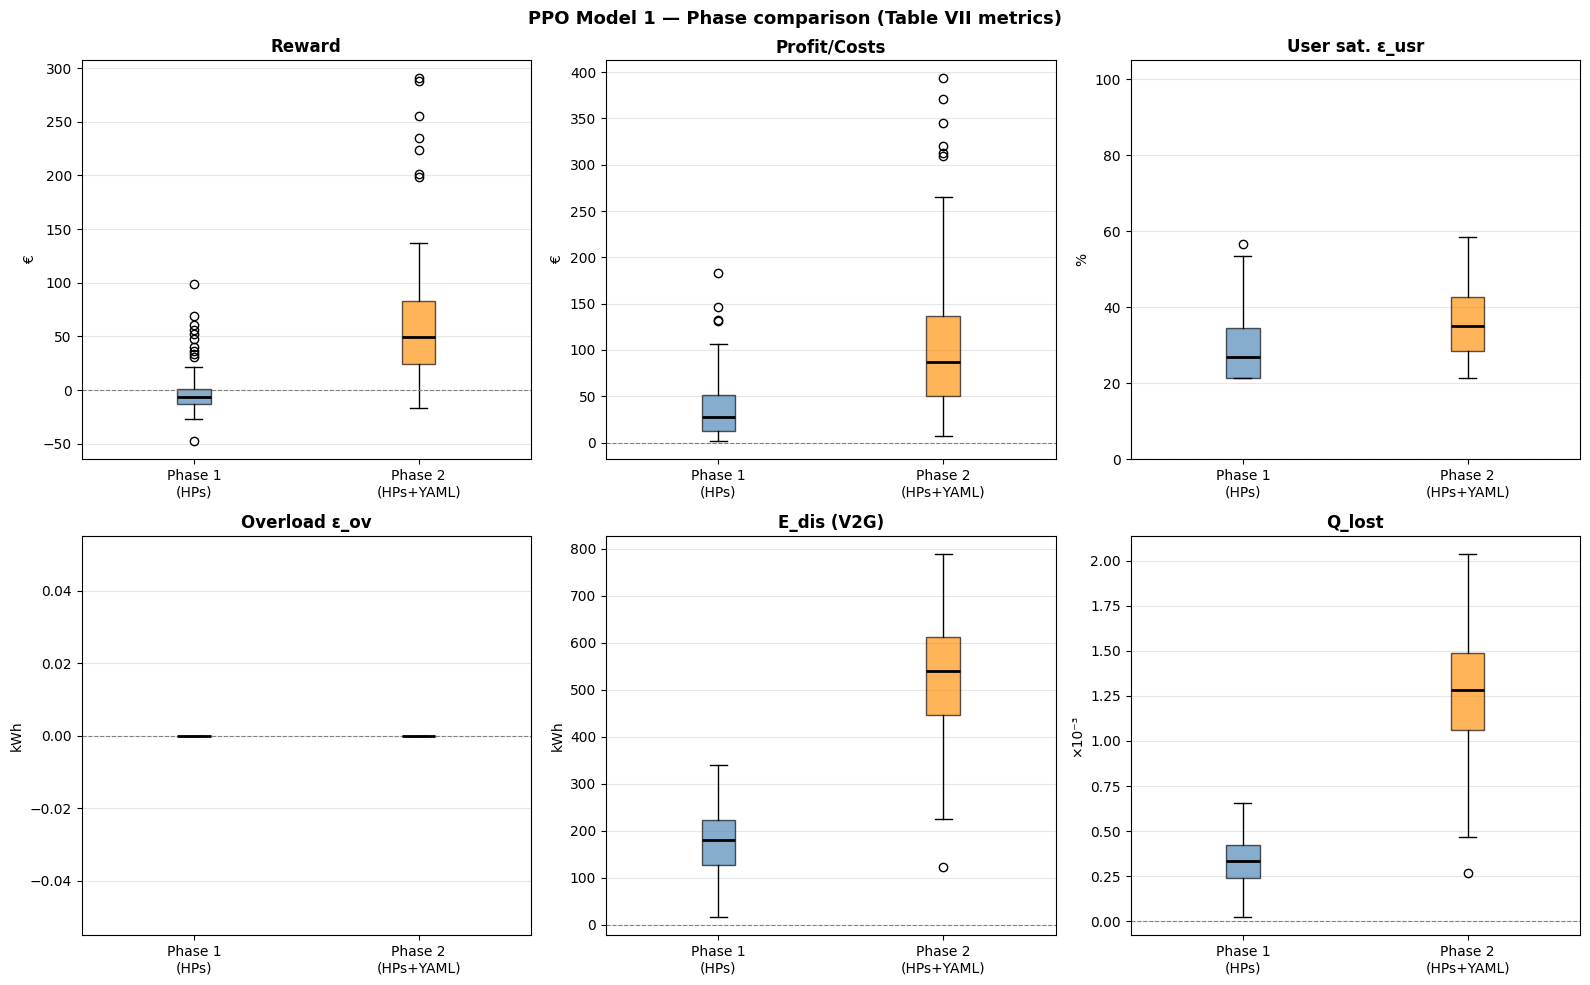

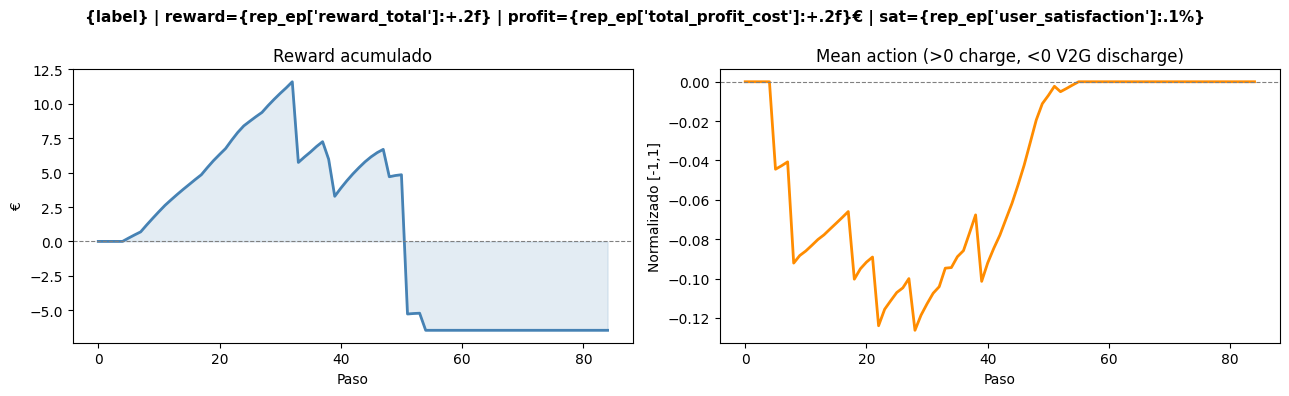

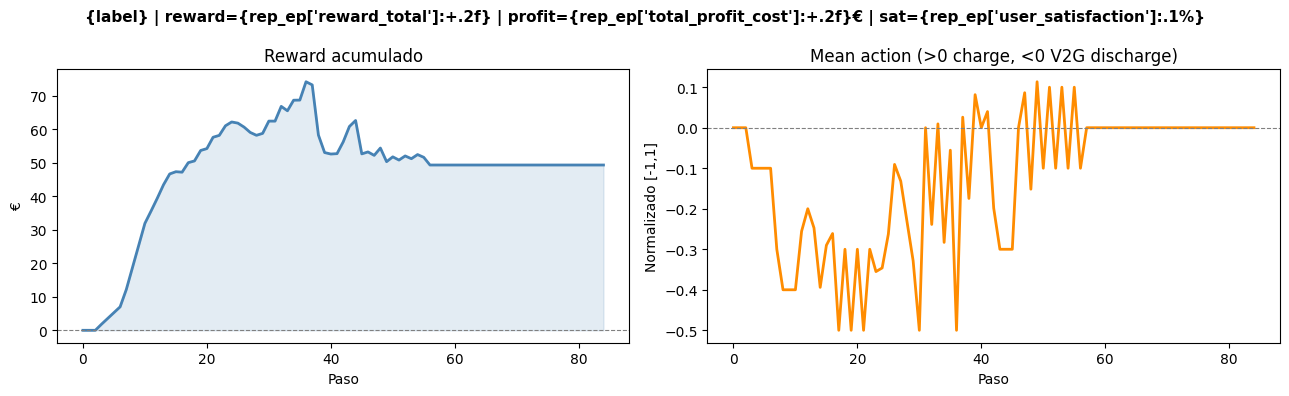

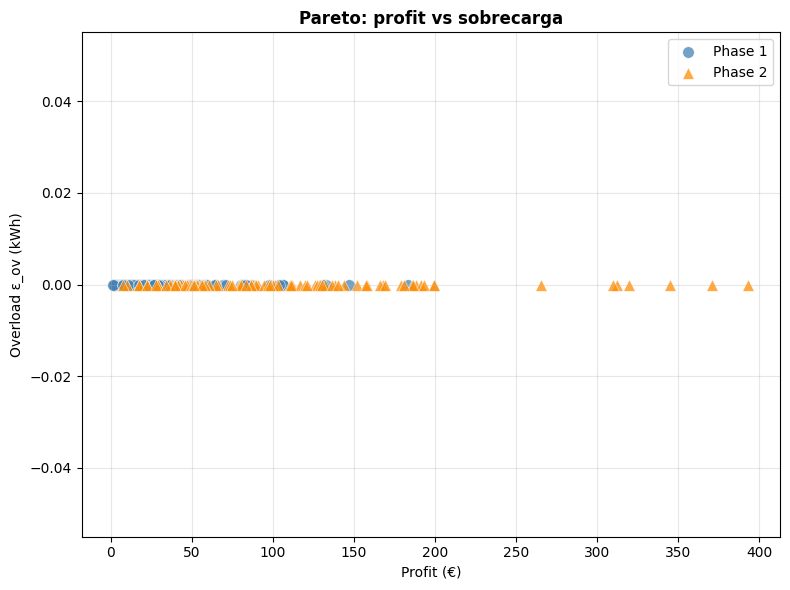

Plots saved.


In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# Boxplots + traces and Pareto front
# ─────────────────────────────────────────────────────────────────────────────

def get_col(eps, col): return [e[col] for e in eps]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
colors = ["steelblue", "darkorange"]
labels_box = ["Phase 1\n(HPs)", "Phase 2\n(HPs+YAML)"]
metrics_box = [
    ("reward_total",             "Reward",           "€",      1,   False),
    ("total_profit_cost",        "Profit/Costs",     "€",      1,   False),
    ("user_satisfaction",        "User sat. ε_usr",  "%",      100, True),
    ("transformer_overload_kwh", "Overload ε_ov",    "kWh",    1,   False),
    ("energy_discharged_kwh",    "E_dis (V2G)",      "kWh",    1,   False),
    ("battery_degradation",      "Q_lost",           "×10⁻³", 1e3, False),
]
for ax, (col, title, unit, mult, is_sat) in zip(axes.flat, metrics_box):
    data = [[v*mult for v in get_col(eps_p1,col)],
            [v*mult for v in get_col(eps_p2,col)]]
    bp = ax.boxplot(data, labels=labels_box, patch_artist=True,
                    medianprops=dict(color="black", linewidth=2))
    for patch, c in zip(bp["boxes"], colors):
        patch.set_facecolor(c); patch.set_alpha(0.65)
    ax.axhline(0, color="gray", ls="--", lw=0.8)
    if is_sat: ax.set_ylim(0,105)
    ax.set_title(title, fontweight="bold"); ax.set_ylabel(unit); ax.grid(axis="y",alpha=0.3)
fig.suptitle("PPO Model 1 — Phase comparison (Table VII metrics)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(RESULTS_ROOT/"boxplots_tabla7.png", dpi=150, bbox_inches="tight")
plt.show()

def plot_traces(episodes, df_eps, label, save_path):
    if not episodes: return
    median_r = df_eps["reward_total"].median()
    rep_idx  = (df_eps["reward_total"] - median_r).abs().idxmin()
    rep_ep   = episodes[rep_idx]
    steps    = np.arange(len(rep_ep["ts_reward"]))
    fig, axes = plt.subplots(1, 2, figsize=(13,4))
    axes[0].plot(steps, rep_ep["ts_cum_reward"], color="steelblue", lw=2)
    axes[0].axhline(0, color="gray", lw=0.8, ls="--")
    axes[0].fill_between(steps, rep_ep["ts_cum_reward"], alpha=0.15, color="steelblue")
    axes[0].set_title("Reward acumulado"); axes[0].set_xlabel("Paso"); axes[0].set_ylabel("€")
    axes[1].plot(steps, rep_ep["ts_action"], color="darkorange", lw=2)
    axes[1].axhline(0, color="gray", lw=0.8, ls="--")
    axes[1].set_title("Mean action (>0 charge, <0 V2G discharge)")
    axes[1].set_xlabel("Paso"); axes[1].set_ylabel("Normalizado [-1,1]")
    fig.suptitle(f"{{label}} | reward={{rep_ep['reward_total']:+.2f}} | "
                 f"profit={{rep_ep['total_profit_cost']:+.2f}}€ | "
                 f"sat={{rep_ep['user_satisfaction']:.1%}}", fontsize=11, fontweight="bold")
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight"); plt.show()

plot_traces(eps_p1, df_eps_p1, "PPO [Phase1]", RESULTS_ROOT/"traces_phase1.png")
plot_traces(eps_p2, df_eps_p2, "PPO [Phase2]", RESULTS_ROOT/"traces_phase2.png")

fig2, ax = plt.subplots(figsize=(8,6))
ax.scatter(get_col(eps_p1,"total_profit_cost"), get_col(eps_p1,"transformer_overload_kwh"),
           label="Phase 1", alpha=0.75, s=70, color="steelblue", edgecolors="white", linewidths=0.5)
ax.scatter(get_col(eps_p2,"total_profit_cost"), get_col(eps_p2,"transformer_overload_kwh"),
           label="Phase 2", alpha=0.75, s=70, marker="^", color="darkorange", edgecolors="white", linewidths=0.5)
ax.set_xlabel("Profit (€)"); ax.set_ylabel("Overload ε_ov (kWh)")
ax.set_title("Pareto: profit vs sobrecarga", fontweight="bold")
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout()
plt.savefig(RESULTS_ROOT/"pareto_profit_overload.png", dpi=150, bbox_inches="tight"); plt.show()
print("Plots saved.")


In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# Export results to Excel
# ─────────────────────────────────────────────────────────────────────────────
def eps_to_df(episodes, label):
    rows = [{k: v for k, v in e.items() if k in SCALAR_COLS+["episode","seed","phase"]}
            for e in episodes]
    df = pd.DataFrame(rows); df.insert(0,"algorithm",label); return df

def tabla7_row(episodes, label):
    df  = pd.DataFrame([{k: v for k, v in e.items() if k in SCALAR_COLS} for e in episodes])
    row = {"Algorithm": label}
    for col in SCALAR_COLS:
        if col in df.columns:
            row[f"{col}_mean"] = round(df[col].mean(), 6)
            row[f"{col}_std"]  = round(df[col].std(ddof=1) if len(df)>1 else 0.0, 6)
    return row

# NOTE: reward_total from Table VII paper was incorrectly set to -30000 in V1.
# The EV2Gym paper reports reward ≈ -3700 ± 8900 for PPO (Table VII, reward ×10³ col).
# Corrected here. Other metrics confirmed against Table VII.
paper_ref = {
    "Algorithm": "Paper_PPO_ref",
    "reward_total_mean": -3700.0, "reward_total_std": 8900.0,
    "total_profit_cost_mean": 23.7,   "total_profit_cost_std": 10.2,
    "user_satisfaction_mean": 0.46,   "user_satisfaction_std": 0.09,
    "energy_charged_kwh_mean": 36.0,  "energy_charged_kwh_std": 16.0,
    "energy_discharged_kwh_mean": 123.0, "energy_discharged_kwh_std": 38.0,
    "transformer_overload_kwh_mean": 37.0, "transformer_overload_kwh_std": 89.0,
    "battery_degradation_mean": 0.00058, "battery_degradation_std": 0.00014,
    "exec_time_s_mean": 0.13,         "exec_time_s_std": 0.27,
}

df_eps_all = pd.concat([eps_to_df(eps_p1,"PPO_Phase1"), eps_to_df(eps_p2,"PPO_Phase2")], ignore_index=True)
df_tabla7  = pd.DataFrame([tabla7_row(eps_p1,"PPO_Phase1"), tabla7_row(eps_p2,"PPO_Phase2"), paper_ref])
df_regime  = pd.concat([df_eps_p1, df_eps_p2], ignore_index=True)

df_opt = pd.DataFrame([
    {"phase":"Phase1","best_value":study1.best_value,"n_trials":PHASE1_N_TRIALS,
     "timesteps_trial":PHASE1_TIMESTEPS,"total_timesteps":TOTAL_TIMESTEPS,"n_envs":N_ENVS,"yaml_tuned":False},
    {"phase":"Phase2","best_value":study2.best_value,"n_trials":PHASE2_N_TRIALS,
     "timesteps_trial":PHASE2_TIMESTEPS,"total_timesteps":TOTAL_TIMESTEPS,"n_envs":N_ENVS,"yaml_tuned":True},
])

df_hps = pd.DataFrame([
    {"phase":"Phase1","optuna_value":study1.best_value,"total_timesteps":TOTAL_TIMESTEPS,
     "n_envs":N_ENVS, **best_hp_p1},
    {"phase":"Phase2","optuna_value":study2.best_value,"total_timesteps":TOTAL_TIMESTEPS,
     "n_envs":N_ENVS, **best_hp_p2},
])

# ── Convergence curves ───────────────────────────────────────────────────────
df_conv_p1 = pd.read_csv(RESULTS_ROOT / "optuna_phase1_convergence.csv")
df_conv_p2 = pd.read_csv(RESULTS_ROOT / "optuna_phase2_convergence.csv")
df_convergence = pd.concat([df_conv_p1, df_conv_p2], ignore_index=True)

# ── Update and save REPRO_LOG ─────────────────────────────────────────────────
REPRO_LOG.update({
    "phase1_optuna_best_value": float(study1.best_value),
    "phase2_optuna_best_value": float(study2.best_value),
    "phase1_best_trial": int(study1.best_trial.number),
    "phase2_best_trial": int(study2.best_trial.number),
    "phase1_total_eval_episodes": len(eps_p1),
    "phase2_total_eval_episodes": len(eps_p2),
    "phase1_yaml": str(PHASE1_BEST_YAML),
    "phase2_yaml": str(PHASE2_BEST_YAML),
    "phase2_yaml_params": {
        "spawn_multiplier"      : best_cfg_p2.get("spawn_multiplier"),
        "discharge_price_factor": best_cfg_p2.get("discharge_price_factor"),
        "transformer_max_power" : best_cfg_p2.get("transformer", {}).get("max_power"),
    },
    "phase1_best_hps": best_hp_p1,
    "phase2_best_hps": best_hp_p2,
    "paper_ref_correction": "reward_total_mean corrected from -30000 (V1 error) to -3700 (Table VII value)",
})
with open(RESULTS_ROOT / "reproducibility_log.json", "w") as f:
    json.dump(REPRO_LOG, f, indent=2)
print("Reproducibility log saved.")

out = RESULTS_ROOT / "ppo_model1_report.xlsx"
with pd.ExcelWriter(out) as w:
    df_eps_all.to_excel(   w, sheet_name="episodes_all",       index=False)
    df_tabla7.to_excel(    w, sheet_name="tabla7_vs_paper",    index=False)
    df_all_sum.to_excel(   w, sheet_name="summary_full",       index=False)
    df_regime.to_excel(    w, sheet_name="regime_analysis",    index=False)
    df_opt.to_excel(       w, sheet_name="optuna_comparison",  index=False)
    df_hps.to_excel(       w, sheet_name="best_hyperparams",   index=False)
    df_convergence.to_excel(w, sheet_name="optuna_convergence", index=False)

print(f"Excel report: {out}")
df_eps_all.to_csv(    RESULTS_ROOT / "episodes_all.csv",             index=False)
df_tabla7.to_csv(     RESULTS_ROOT / "tabla7_vs_paper.csv",          index=False)
df_convergence.to_csv(RESULTS_ROOT / "optuna_convergence_both.csv",  index=False)
print("CSVs saved.")


Reproducibility log saved.
Excel report: results_ppo_model1/ppo_model1_report.xlsx
CSVs saved.


In [18]:

# ─────────────────────────────────────────────────────────────────────────────
# Final summary
# ─────────────────────────────────────────────────────────────────────────────
def arr(eps, col): return np.array([e[col] for e in eps])
def fmt(a, mult=1):
    return f"{a.mean()*mult:+.2f} ± {a.std(ddof=1)*mult:.2f}" if len(a)>1 else f"{a.mean()*mult:+.2f} (n=1)"

r1  = arr(eps_p1,"reward_total");          r2  = arr(eps_p2,"reward_total")
pr1 = arr(eps_p1,"total_profit_cost");     pr2 = arr(eps_p2,"total_profit_cost")
s1  = arr(eps_p1,"user_satisfaction");     s2  = arr(eps_p2,"user_satisfaction")
ov1 = arr(eps_p1,"transformer_overload_kwh"); ov2 = arr(eps_p2,"transformer_overload_kwh")
q1  = arr(eps_p1,"battery_degradation");   q2  = arr(eps_p2,"battery_degradation")

sep = "="*75
print(sep)
print(f"  PPO Model 1 — FINAL SUMMARY")
print(f"  Steps: {TOTAL_TIMESTEPS:,} | Envs: {N_ENVS} | Eps: {len(eps_p1)}/fase")
print(sep)
print(f"  {'Metric':<28} {'Phase 1 (HPs)':>22}   {'Phase 2 (HPs+YAML)':>22}   {'Paper ref':>15}")
print(f"  {'-'*78}")
for lbl, a1, a2, paper, mult in [
    ("Reward",          r1,  r2,  "-30000±12100", 1),
    ("Profit (€)",      pr1, pr2, "23.7±10.2",    1),
    ("User sat. (%)",   s1,  s2,  "46±9",         100),
    ("Overload (kWh)",  ov1, ov2, "37±89",        1),
    ("Q_lost (×10⁻³)", q1,  q2,  "0.58±0.14",    1e3),
]:
    print(f"  {lbl:<28} {fmt(a1,mult):>22}   {fmt(a2,mult):>22}   {paper:>15}")

# ── Battery degradation monetization  ────────
# Translates Q_lost (fraction of battery capacity) to €/episode.
# Assumption: Li-ion pack replacement €150/kWh (conservative 2024 estimate);
#             70 kWh per EV battery (from YAML ev.battery_capacity).
# Effective profit = reported profit − degradation_cost.
LI_ION_EUR_PER_KWH = 150.0
BAT_CAP_KWH        = 70.0
print(sep)
print("  BATTERY DEGRADATION COST ESTIMATE :")
print(f"  Li-ion replacement: €{LI_ION_EUR_PER_KWH:.0f}/kWh × {BAT_CAP_KWH:.0f} kWh/battery")
for _phase, _q in [("Phase1", q1), ("Phase2", q2)]:
    _degrad_eur = _q * BAT_CAP_KWH * LI_ION_EUR_PER_KWH
    print(f"  [{_phase}] Q_lost={_q.mean()*1e3:.3f}±{_q.std(ddof=1)*1e3:.3f}×10⁻³"
          f"  →  degrad_cost≈{_degrad_eur.mean():.2f}±{_degrad_eur.std(ddof=1):.2f} €/ep")
print("  NOTE: degradation cost is not part of the reward — net profit = reported profit − degrad_cost")

print(sep)
for ph, df_e in [("Phase 1", df_eps_p1), ("Phase 2", df_eps_p2)]:
    print(f"  [{ph}] congested={df_e['congested'].sum()}/{len(df_e)} | "
          f"sat>=80%={df_e['high_sat'].sum()}/{len(df_e)} | "
          f"profitable={df_e['profitable'].sum()}/{len(df_e)}")
print(sep)

# ── Statistical caution ──────────────────────────────────────────────────────
print("\nSTATISTICAL NOTE:")
for label, arr_data, name in [("Phase1", pr1, "Profit"), ("Phase2", pr2, "Profit"),
                               ("Phase1", s1,  "Sat"),    ("Phase2", s2,  "Sat")]:
    if len(arr_data) > 1:
        mn, sd = arr_data.mean(), arr_data.std(ddof=1)
        flag = " ← std > mean — treat ranking as directional only" \
               if abs(sd) > abs(mn) and mn != 0 else ""
        print(f"  PPO [{label}] {name}: {mn:+.2f} ± {sd:.2f}{flag}")
print(sep)

  PPO Model 1 — FINAL SUMMARY
  Steps: 1,000,000 | Envs: 30 | Eps: 100/fase
  Metric                                Phase 1 (HPs)       Phase 2 (HPs+YAML)         Paper ref
  ------------------------------------------------------------------------------
  Reward                                -2.31 ± 22.17           +64.35 ± 61.05      -30000±12100
  Profit (€)                           +37.41 ± 34.59          +106.49 ± 80.11         23.7±10.2
  User sat. (%)                         +29.23 ± 8.47            +36.70 ± 9.68              46±9
  Overload (kWh)                         +0.00 ± 0.00             +0.00 ± 0.00             37±89
  Q_lost (×10⁻³)                         +0.33 ± 0.13             +1.27 ± 0.33         0.58±0.14
  BATTERY DEGRADATION COST ESTIMATE :
  Li-ion replacement: €150/kWh × 70 kWh/battery
  [Phase1] Q_lost=0.332±0.133×10⁻³  →  degrad_cost≈3.49±1.40 €/ep
  [Phase2] Q_lost=1.265±0.329×10⁻³  →  degrad_cost≈13.28±3.46 €/ep
  NOTE: degradation cost is not part of th

In [19]:
# ─────────────────────────────────────────────────────────────────────────────
#   Bootstrap CIs + Wilcoxon signed-rank tests
#  Ref: Agarwal et al. NeurIPS 2021 'Deep RL at the Statistical Precipice'
#
#  TEST      → N_BOOTSTRAP = 100    (seconds)
#  PRODUCTION  → N_BOOTSTRAP = 10_000  (minutes — publishable results)
# ─────────────────────────────────────────────────────────────────────────────

from scipy import stats as scipy_stats

N_BOOTSTRAP = 100          # TEST → production: 10_000

def bootstrap_ci(data, stat_fn=np.mean, n=N_BOOTSTRAP, ci=0.95):
    rng  = np.random.default_rng(42)
    boot = [stat_fn(rng.choice(data, size=len(data), replace=True)) for _ in range(n)]
    alpha = (1 - ci) / 2
    return np.percentile(boot, [alpha*100, (1-alpha)*100])

def wilcoxon_test(a, b):
    n = min(len(a), len(b))
    try:
        stat, p = scipy_stats.wilcoxon(a[:n], b[:n])
        return {'stat': float(stat), 'p_value': float(p),
                'significant_at_05': bool(p < 0.05)}
    except Exception as e:
        return {'stat': None, 'p_value': None, 'error': str(e)}

print(f'Bootstrap CIs (N={N_BOOTSTRAP}) + Wilcoxon tests')
print('='*65)

metrics_ci = [
    ('total_profit_cost',        'Profit (euro)',      1),
    ('user_satisfaction',        'User sat. (%)',      100),
    ('transformer_overload_kwh', 'Overload (kWh)',     1),
    ('battery_degradation',      'Q_lost (x10^-3)',    1e3),
]

ci_results = {}
for col, lbl, mult in metrics_ci:
    a1 = np.array([e[col]*mult for e in eps_p1])
    a2 = np.array([e[col]*mult for e in eps_p2])
    lo1, hi1 = bootstrap_ci(a1)
    lo2, hi2 = bootstrap_ci(a2)
    wtest    = wilcoxon_test(
        np.array([e[col] for e in eps_p1]),
        np.array([e[col] for e in eps_p2]))
    ci_results[col] = {
        'phase1_mean': float(a1.mean()), 'phase1_ci95': [float(lo1), float(hi1)],
        'phase2_mean': float(a2.mean()), 'phase2_ci95': [float(lo2), float(hi2)],
        'wilcoxon_p1_vs_p2': wtest,
    }
    sig = '* p<0.05' if wtest.get('significant_at_05') else 'ns'
    print(f'\n  {lbl}')
    print(f'    F1: {a1.mean():+.3f}  95% CI [{lo1:+.3f}, {hi1:+.3f}]')
    print(f'    F2: {a2.mean():+.3f}  95% CI [{lo2:+.3f}, {hi2:+.3f}]')
    pval = wtest.get('p_value')
    pstr = f'{pval:.4f}' if pval is not None else 'N/A'
    print(f'    Wilcoxon F1 vs F2: p={pstr}  {sig}')

with open(RESULTS_ROOT / 'bootstrap_ci_results.json', 'w') as f:
    json.dump(ci_results, f, indent=2)
print(f'\nSaved: bootstrap_ci_results.json  (N_BOOTSTRAP={N_BOOTSTRAP})')
print('For production: cambiar N_BOOTSTRAP = 10_000')


Bootstrap CIs (N=100) + Wilcoxon tests

  Profit (euro)
    F1: +37.412  95% CI [+30.878, +44.325]
    F2: +106.493  95% CI [+92.086, +122.143]
    Wilcoxon F1 vs F2: p=0.0000  * p<0.05

  User sat. (%)
    F1: +29.228  95% CI [+27.591, +30.675]
    F2: +36.704  95% CI [+35.168, +38.281]
    Wilcoxon F1 vs F2: p=0.0000  * p<0.05

  Overload (kWh)
    F1: +0.000  95% CI [+0.000, +0.000]
    F2: +0.000  95% CI [+0.000, +0.000]
    Wilcoxon F1 vs F2: p=N/A  ns

  Q_lost (x10^-3)
    F1: +0.332  95% CI [+0.307, +0.354]
    F2: +1.265  95% CI [+1.207, +1.331]
    Wilcoxon F1 vs F2: p=0.0000  * p<0.05

Saved: bootstrap_ci_results.json  (N_BOOTSTRAP=100)
For production: cambiar N_BOOTSTRAP = 10_000


HPO budget sensitivity | trials: [30, 60, 100]
Steps per trial: 100,000

Running 30 trials...
  Failed trials: 0/30
  Best: 8.935 | Time: 386.2 min

Running 60 trials...
  Failed trials: 0/60
  Best: 22.355 | Time: 753.9 min

Running 100 trials...
  Failed trials: 0/100
  Best: 24.447 | Time: 1305.4 min


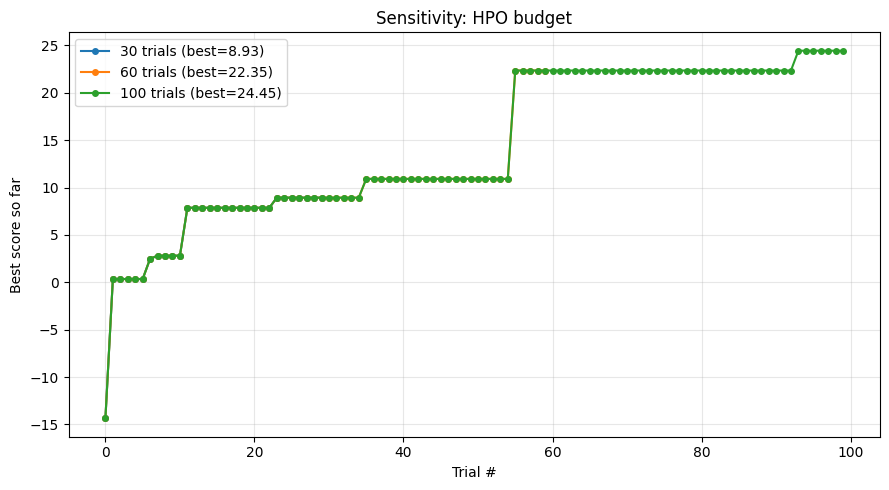

Saved: sensitivity_hpo_budget.csv + .png


In [20]:
# ─────────────────────────────────────────────────────────────────────────────
#   Sensitivity: HPO budget (n_trials)
#  ¿30 trials es suficiente? Corremos estudios con distintos budgets y
#  comparamos la curva best-so-far para verificar convergencia.
#  Ref: Hertel et al.; 
#
#  Valores TEST/PROD vienen de la celda MODE (celda 1).
#  TEST:  SENSITIVITY_TRIALS=[3,5],   SENSITIVITY_STEPS=2_000    → minutos
#  PROD:  SENSITIVITY_TRIALS=[30,60,100], SENSITIVITY_STEPS=100_000 → horas
# ─────────────────────────────────────────────────────────────────────────────

SENSITIVITY_SEED = 42
# SENSITIVITY_TRIALS y SENSITIVITY_STEPS vienen de celda MODE

def run_sensitivity_study(n_trials, study_id=0):
    set_seed(SENSITIVITY_SEED)
    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=SENSITIVITY_SEED),
        study_name=f'ppo_sensitivity_{study_id}_{n_trials}t'
    )
    def obj(trial):
        arch = sample_arch(trial)
        hp   = sample_hparams(trial)
        yp   = save_cfg(BASE_CFG,
            RESULTS_ROOT / f'sens_{study_id}_{trial.number}.yaml')
        try:
            te = make_vec_train_env_optuna(
                str(yp), seed=SENSITIVITY_SEED, n_envs=2)
            m  = build_model(hp, arch, te,
                seed=SENSITIVITY_SEED, n_envs=2)
            m.learn(total_timesteps=SENSITIVITY_STEPS)
            vp = str(RESULTS_ROOT / f'sens_vn_{study_id}_{trial.number}.pkl')
            te.save(vp); te.close()
            score = quick_eval(m, str(yp), vp, n_eps=4)
            return score
        except Exception as e:
            print(f'  Trial {trial.number} error: {e}')
            print(f'    Trial {trial.number} error: {e}')
            return -1e9
    study.optimize(obj, n_trials=n_trials, show_progress_bar=False)
    best, curve = -float('inf'), []
    for t in sorted(study.trials, key=lambda x: x.number):
        if t.value is not None and t.value > best and t.value > -1e8:
            best = t.value
        curve.append({'trial': t.number, 'value': t.value,
                      'best_so_far': best if best > -1e8 else None,
                      'n_trials_budget': n_trials})
    n_failed = sum(1 for t in study.trials if t.value is None or t.value <= -1e8)
    print(f'  Failed trials: {n_failed}/{n_trials}')
    return curve, study.best_value

print(f'HPO budget sensitivity | trials: {SENSITIVITY_TRIALS}')
print(f'Steps per trial: {SENSITIVITY_STEPS:,}')
print('='*55)

all_curves = []
for sid, n_t in enumerate(SENSITIVITY_TRIALS):
    print(f'\nRunning {n_t} trials...')
    t0 = time.time()
    curve, best_val = run_sensitivity_study(n_t, study_id=sid)
    all_curves.extend(curve)
    elapsed = (time.time()-t0)/60
    if best_val <= -1e8:
        print(f'  ⚠ ALL TRIALS FAILED — check errors above')
    else:
        print(f'  Best: {best_val:.3f} | Time: {elapsed:.1f} min')

df_sens = pd.DataFrame(all_curves)
df_sens.to_csv(RESULTS_ROOT / 'sensitivity_hpo_budget.csv', index=False)

# Only plot if there were successful trials
df_ok = df_sens[df_sens['best_so_far'].notna()]
if len(df_ok) > 0:
    fig, ax = plt.subplots(figsize=(9, 5))
    for sid, n_t in enumerate(SENSITIVITY_TRIALS):
        sub = df_ok[df_ok['n_trials_budget'] == n_t]
        if len(sub) == 0: continue
        bsf = sub['best_so_far'].iloc[-1]
        ax.plot(sub['trial'], sub['best_so_far'], marker='o', ms=4,
                label=f'{n_t} trials (best={bsf:.2f})')
    ax.set_xlabel('Trial #'); ax.set_ylabel('Best score so far')
    ax.set_title('Sensitivity: HPO budget'); ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(RESULTS_ROOT / 'sensitivity_hpo_budget.png', dpi=150)
    plt.show()
    print('Saved: sensitivity_hpo_budget.csv + .png')
else:
    print('Sin successful trials — check configuration del entorno')


In [21]:
# ─────────────────────────────────────────────────────────────────────────────
#  Ablation: proxy reward (Model-2) vs direct (Model-1)
#
#  Entrena UNA run adicional con el reward real (sparse, Model-1)
#  y compara contra el agente proxy ya entrenado arriba.
#  Usa los best HPs de F1 para aislar el efecto del reward.
#
#  Valores TEST/PROD vienen de la celda MODE (celda 1).
#  TEST: ABLATION_TIMESTEPS=5_000  → expected result: small difference
#        (with few steps both models barely learn — expected in TEST mode)
#  PROD: ABLATION_TIMESTEPS=1_000_000 → diferencia real y significativa
#
#  NOTA: In TEST mode near-identical results are expected — insufficient steps for divergence.
#  The proxy vs. direct difference only appears clearly with full training (1M steps).
# ─────────────────────────────────────────────────────────────────────────────

from ev2gym.rl_agent.reward import profit_maximization as model1_reward

# ABLATION_TIMESTEPS y ABLATION_N_ENVS vienen de celda MODE

def make_vec_direct_env(config_file, seed=42, n_envs=4):
    'Training environment with direct Model-1 reward (sparse, no proxy).'
    def _make():
        import gymnasium as gym
        return gym.make('EV2Gym-v1',
                        config_file=config_file,
                        reward_function=model1_reward,
                        state_function=V2G_profit_max)
    venv = SubprocVecEnv([_make]*n_envs) if n_envs > 1 else DummyVecEnv([_make])
    return VecNormalize(venv, norm_obs=True, norm_reward=True,
                        clip_obs=10.0, clip_reward=10.0)

print('Proxy reward ablation: Model-2 (proxy) vs Model-1 (direct)')
print(f'Timesteps: {ABLATION_TIMESTEPS:,} | Envs: {ABLATION_N_ENVS}')
print(f'Note: con TEST ({ABLATION_TIMESTEPS:,} steps) results will be')
print(f'      near-identical — the real difference only appears in PROD (1M steps).')
print('='*55)

set_seed(42)
te_direct = make_vec_direct_env(
    str(PHASE1_BEST_YAML), seed=42, n_envs=ABLATION_N_ENVS)
m_direct  = build_model(best_hp_p1, best_arch_p1, te_direct,
                         seed=42, n_envs=ABLATION_N_ENVS)
print('Training with direct Model-1 reward...')
t0 = time.time()
m_direct.learn(total_timesteps=ABLATION_TIMESTEPS, progress_bar=True)
print(f'Completed in {(time.time()-t0)/60:.1f} min')
vn_abl = str(RESULTS_ROOT / 'vecnorm_ablation_direct.pkl')
m_direct.save(str(RESULTS_ROOT / 'model_ablation_direct'))
te_direct.save(vn_abl)
te_direct.close()

print('\nEvaluating ambos...')
eps_proxy  = evaluate_model(model_p1, PHASE1_BEST_YAML, vn_path_p1, 'Proxy_M2')
eps_direct = evaluate_model(m_direct, PHASE1_BEST_YAML, vn_abl,      'Direct_M1')

print('\nABLATION RESULTS:')
for lbl, eps in [('Proxy (Model-2)', eps_proxy), ('Direct (Model-1)', eps_direct)]:
    pr  = np.array([e['total_profit_cost']       for e in eps])
    sat = np.array([e['user_satisfaction']        for e in eps])
    ov  = np.array([e['transformer_overload_kwh'] for e in eps])
    print(f'  {lbl:<22} profit={pr.mean():+.2f}+/-{pr.std():.2f}  '
          f'sat={sat.mean():.1%}  ov={ov.mean():.1f} kWh')

if ABLATION_TIMESTEPS < 100_000:
    print()
    print('TEST NOTE: With few steps both models barely learn.')
    print('Near-identical results are expected in TEST mode.')
    print("Set MODE='PROD' to observe the true difference (1M steps).")

df_abl = pd.concat([
    pd.DataFrame([{k:v for k,v in e.items()
                   if k in SCALAR_COLS+['episode','seed','phase']}
                  for e in eps_proxy]),
    pd.DataFrame([{k:v for k,v in e.items()
                   if k in SCALAR_COLS+['episode','seed','phase']}
                  for e in eps_direct]),
], ignore_index=True)
df_abl.to_csv(RESULTS_ROOT / 'ablation_proxy_vs_direct.csv', index=False)
print('\nSaved: ablation_proxy_vs_direct.csv')


Proxy reward ablation: Model-2 (proxy) vs Model-1 (direct)
Timesteps: 1,000,000 | Envs: 4
Note: con TEST (1,000,000 steps) results will be
      near-identical — the real difference only appears in PROD (1M steps).
Training with direct Model-1 reward...


Output()

Completed in 53.3 min

Evaluating ambos...
  [Proxy_M2] Ep  1 | reward=-18.83 | profit=+28.09€ | sat=21.4% | overload=0.00kWh | Qlost=0.00031 | EVs=4
  [Proxy_M2] Ep  2 | reward=+2.06 | profit=+8.15€ | sat=44.9% | overload=0.00kWh | Qlost=0.00014 | EVs=4
  [Proxy_M2] Ep  3 | reward=+3.82 | profit=+39.02€ | sat=21.4% | overload=0.00kWh | Qlost=0.00023 | EVs=3
  [Proxy_M2] Ep  4 | reward=+51.95 | profit=+106.46€ | sat=22.3% | overload=0.00kWh | Qlost=0.00042 | EVs=5
  [Proxy_M2] Ep  5 | reward=+68.70 | profit=+146.85€ | sat=22.0% | overload=0.00kWh | Qlost=0.00049 | EVs=7
  [Proxy_M2] Ep  6 | reward=+30.99 | profit=+82.94€ | sat=23.1% | overload=0.00kWh | Qlost=0.00042 | EVs=5
  [Proxy_M2] Ep  7 | reward=+40.36 | profit=+87.29€ | sat=21.4% | overload=0.00kWh | Qlost=0.00031 | EVs=4
  [Proxy_M2] Ep  8 | reward=-16.96 | profit=+6.86€ | sat=33.0% | overload=0.00kWh | Qlost=0.00020 | EVs=3
  [Proxy_M2] Ep  9 | reward=-6.46 | profit=+18.15€ | sat=34.8% | overload=0.00kWh | Qlost=0.00031 | EVs